Начинаем итерации метода штрафных функций...

mu =        1, решение x* = [1.960512, 4.928125], F(x*) = -8.647396, штраф = 1.627784e+00, кол-во итераций = 11
mu =       10, решение x* = [1.609727, 4.468536], F(x*) = -5.632918, штраф = 2.117683e-02, кол-во итераций = 15
mu =      100, решение x* = [1.566566, 4.441158], F(x*) = -5.246437, штраф = 2.279284e-04, кол-во итераций = 8
mu =     1000, решение x* = [1.562056, 4.438715], F(x*) = -5.205344, штраф = 2.298228e-06, кол-во итераций = 9
mu =    10000, решение x* = [1.561603, 4.438474], F(x*) = -5.201206, штраф = 2.299343e-08, кол-во итераций = 9

Процесс итераций завершён.

Итоговое решение (при самом большом му):
 x* = [1.56160318 4.43847393]
 F(x*) = -5.201206233712632
 Штраф = 2.2993429181983028e-08

Проверка ограничений g_i(x*) <= 0:
 g1(x*) = 0.000131
 g2(x*) = 0.000077
 g3(x*) = -1.561603
 g4(x*) = -4.438474


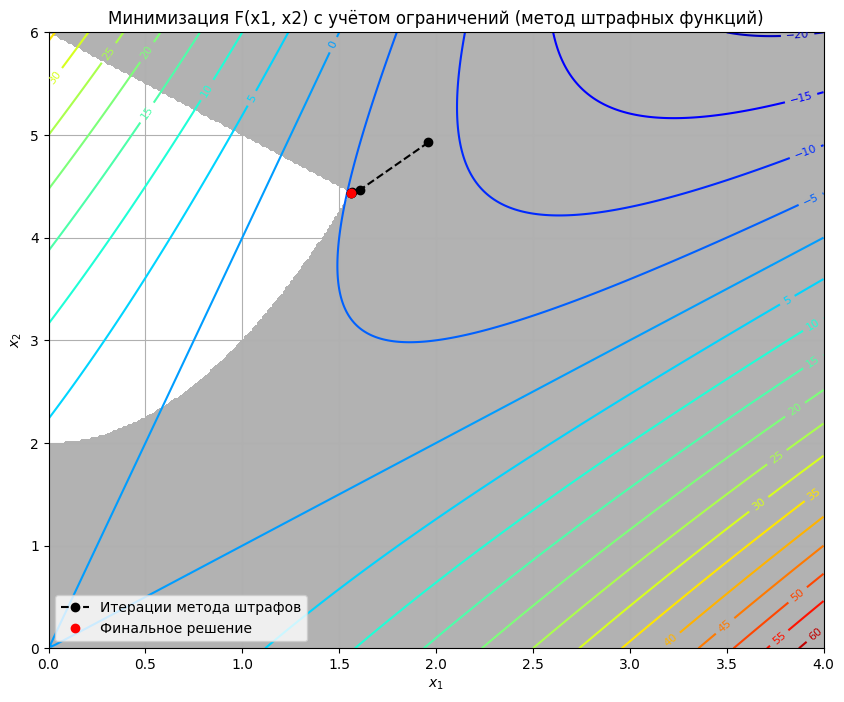

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from scipy.optimize import minimize

# --------------------------------------------------------------------
# 1. Определение исходной функции F(x1, x2)
# --------------------------------------------------------------------
def F(x):
    """
    Целевая функция F(x1, x2) = 4*x1^2 - 5*x1*x2 + x2^2.
    x - это массив numpy: x = [x1, x2].
    """
    x1, x2 = x
    return 4*x1**2 - 5*x1*x2 + x2**2

# --------------------------------------------------------------------
# 2. Определение функций-ограничений g_i(x1, x2) <= 0
#    и штрафной функции P(x) = Σ (max(0, g_i(x)))^2
# --------------------------------------------------------------------
def constraints(x):
    """
    Возвращает список значений g_i(x).
    Все g_i(x) должны быть <= 0 в допустимой области.
    """
    x1, x2 = x
    g1 = x1**2 - x2 + 2      # x1^2 - x2 + 2 <= 0
    g2 = x1 + x2 - 6         # x1 + x2 - 6 <= 0
    g3 = -x1                 # -x1 <= 0  (эквивалентно x1 >= 0)
    g4 = -x2                 # -x2 <= 0  (эквивалентно x2 >= 0)
    return [g1, g2, g3, g4]

def penalty(x):
    """
    Квадратичная штрафная функция:
    P(x) = Σ (max(0, g_i(x)))^2.
    """
    gs = constraints(x)
    return sum(max(0, gi)**2 for gi in gs)

# --------------------------------------------------------------------
# 3. Итоговая функция для неограниченной минимизации:
#    L(x, mu) = F(x) + mu * P(x)
# --------------------------------------------------------------------
def L(x, mu):
    return F(x) + mu * penalty(x)

# --------------------------------------------------------------------
# 4. Параметры метода штрафных функций и начальное приближение
# --------------------------------------------------------------------
# Список коэффициентов штрафа. Можно брать последовательность [1, 10, 100, 1000] и т.п.
penalty_coefs = [1, 10, 100, 1000, 10000]

# Начальная точка (можно взять (0, 0) или что-то другое).
# (0,0) формально не удовлетворяет g1(0,0)=2<=0? Нет. Но метод штрафов сам "вытолкнет" решение в допустимую область.
x0 = np.array([0.0, 0.0])

# Для логирования сохраним промежуточные результаты
solutions = []
func_values = []
penalty_values = []

# --------------------------------------------------------------------
# 5. Цикл по возрастанию mu: решаем неограниченную задачу minimize(L(x, mu))
# --------------------------------------------------------------------
print("Начинаем итерации метода штрафных функций...\n")

for mu in penalty_coefs:
    # Определяем анонимную функцию (лямбда), зависящую от x
    def objective_for_minimize(x):
        return L(x, mu)
    
    # Запускаем неограниченную минимизацию из текущей точки x0
    res = minimize(objective_for_minimize, x0, method='BFGS')
    
    # Сохраняем результаты
    x_opt = res.x
    f_opt = F(x_opt)
    p_opt = penalty(x_opt)
    
    # Логируем в консоль
    print(f"mu = {mu:8g}, "
          f"решение x* = [{x_opt[0]:.6f}, {x_opt[1]:.6f}], "
          f"F(x*) = {f_opt:.6f}, штраф = {p_opt:.6e}, "
          f"кол-во итераций = {res.nit}")
    
    # Обновляем начальную точку для следующей итерации
    x0 = x_opt
    
    # Запоминаем в списки
    solutions.append(x_opt)
    func_values.append(f_opt)
    penalty_values.append(p_opt)

print("\nПроцесс итераций завершён.")

# --------------------------------------------------------------------
# 6. Анализ результатов:
#    - На больших mu решение должно удовлетворять всем ограничениям
#    - Выведем финальное решение
# --------------------------------------------------------------------
final_solution = solutions[-1]
final_F = func_values[-1]
final_pen = penalty_values[-1]

print("\nИтоговое решение (при самом большом му):")
print(f" x* = {final_solution}")
print(f" F(x*) = {final_F}")
print(f" Штраф = {final_pen}")
print("\nПроверка ограничений g_i(x*) <= 0:")
gs_final = constraints(final_solution)
for i, gi in enumerate(gs_final, start=1):
    print(f" g{i}(x*) = {gi:.6f}")

# --------------------------------------------------------------------
# 7. Построение графиков:
#    - Линии уровня функции F(x1, x2)
#    - Область, где выполняются g1 <= 0, g2 <= 0, x1 >= 0, x2 >= 0
#    - Найденная точка
# --------------------------------------------------------------------
# Чтобы построить контуры, возьмём сетку в некотором прямоугольнике:
x1_min, x1_max = 0, 4
x2_min, x2_max = 0, 6
N = 300

x1_vals = np.linspace(x1_min, x1_max, N)
x2_vals = np.linspace(x2_min, x2_max, N)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Вычислим значения F на сетке
F_vals = 4*X1**2 - 5*X1*X2 + X2**2

# Функция, которая проверяет, что точка (x1, x2) лежит в допустимой области
# (т.е. все g_i(x1, x2) <= 0).
def is_feasible(x1, x2):
    g1 = x1**2 - x2 + 2
    g2 = x1 + x2 - 6
    g3 = -x1
    g4 = -x2
    return (g1 <= 0) and (g2 <= 0) and (g3 <= 0) and (g4 <= 0)

# Создадим матрицу для "маски" допустимой области
feasible_mask = np.zeros_like(F_vals, dtype=bool)

for i in range(N):
    for j in range(N):
        x1_ij = X1[i, j]
        x2_ij = X2[i, j]
        if is_feasible(x1_ij, x2_ij):
            feasible_mask[i, j] = True

plt.figure(figsize=(10, 8))

# 1) Контурные линии функции F
cs = plt.contour(X1, X2, F_vals, levels=20, cmap='jet')
plt.clabel(cs, inline=1, fontsize=8)

# 2) Заштрихуем или закрасим допустимую область
#    Для наглядности можно рисовать полупрозрачную маску
plt.contourf(X1, X2, feasible_mask, levels=[-0.5, 0.5], colors=['none', 'lightgreen'], alpha=0.3)

# 3) Отметим итоговую точку и некоторые промежуточные
sols = np.array(solutions)
plt.plot(sols[:, 0], sols[:, 1], 'o--k', label='Итерации метода штрафов')
plt.plot(final_solution[0], final_solution[1], 'ro', label='Финальное решение')

plt.xlim([x1_min, x1_max])
plt.ylim([x2_min, x2_max])
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Минимизация F(x1, x2) с учётом ограничений (метод штрафных функций)')
plt.legend()
plt.grid(True)
plt.show()
